<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A5_Multi_Step_Forecasting.ipynb)

# Tomorrow, One Hour at a Time: the Autoregressive Forecast

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

You have a model that predicts **one hour ahead**. You need **twenty-four**. The obvious move is to run it, take
its answer, pretend that answer is the last real reading, and run it again - twenty-four times. That is the
**recursive** or **autoregressive** forecast, and it is the one most people reach for first.

It also has a trap in it, and this notebook is about finding the trap:

- your own errors become tomorrow's inputs, so a small mistake at hour 1 is an input at hour 2
- and the *other* columns - temperature, humidity - have to come from somewhere too, for hours that have not
  happened yet

We build it, score it **hour by hour** so you can watch the error grow, and look at a few forecast days up close.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 18 — Tomorrow, three ways: recursive, direct, multi-output
- Setup: the capstone's multivariate one-step LSTM (last 24 hours -> next hour, demand's own past in the window). The question: how do you get 24 hours out of it?
- RECURSIVE: predict hour 1, write it into the demand column, slide the window, predict hour 2... Draw the window sliding on screen. The trap: after a few steps the window is mostly your own guesses.
- The covariate problem is the point of the video: for the future rows you need the clock (known - free), the weather (NOT known - use a forecast; here we cheat with the actuals and CALL it perfect foresight, then show the honest version with the weather frozen), and past demand (your own predictions).
- Exposure bias: the model trained on TRUE past demand, then runs on its own predictions. Errors compound - read the curve: 33 MW at hour 1 (best of everything), 331 at hour 24 with perfect weather, 414 with the weather frozen - WORSE than seasonal naive (227) from about hour 8 on.
- DIRECT: retrain the same model with the target shifted h hours out - a separate model per horizon (we do 1, 6, 12, 24: 42 / 142 / 178 / 207 MW). No rolling, no fake inputs; the cost is 24 models.
- MULTI-OUTPUT: Dense(24), the capstone. One model, one shot: 87 / 139 / 171 / 206 MW - weak at hour 1 (it's learning the whole day at once), tied with direct by hour 24, and both beat seasonal naive. Say which you'd ship and why (direct/MIMO for ops; recursive only for the first few hours).
- Real life: the weather column at future hours comes from the NWS forecast (we have a pipeline for that in class) - and the forecast's error becomes yours.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import Input, LSTM, Dense
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)          # reproducibility: seed numpy, python and tensorflow
tf.config.experimental.enable_op_determinism()   # ...and make the ops themselves deterministic,
                                                 # so re-running this notebook gives the SAME numbers

There are three ways to get from a one-step model to a whole day. **This notebook builds the first one.**
The other two are drawn here so you know what you are choosing between - they arrive in a later course.

<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/Module4/img/m4_multistep_strategies.png" width="100%" alt="recursive vs direct vs multi-output"/>

Watch the **dashed red loop** in strategy 1. That loop is the only place in any of these diagrams where a model
is fed its own guess, and everything interesting below comes out of it.

## Data and the one-step engine

Same prep as the capstone. The one-step LSTM is the engine every strategy starts from.

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

Target in the **last column**, then:

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of **every column, the target included**. Yesterday's demand is the most useful input there is.
- y is the target **`ahead` steps (1 = the very next step)** after the window ends.

Result: X is `(samples, n_steps, n_features)`.


In [2]:
# same prep as the demand capstone: sort, fill, clock features, Demand LAST, train 2017-18 / test 2019
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"]).sort_values("Datetime").set_index("Datetime").ffill()

def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
data  = add_clock(df.loc["2017-01-01":"2019-12-31"])[feats]
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]

sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # target-only scaler to get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_sequences(seqs, n_steps, ahead=1):
    """inputs = the past n_steps rows (every column); target = Demand `ahead` steps after the window ends"""
    X, y = [], []
    for i in range(len(seqs) - n_steps - ahead + 1):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps+ahead-1, -1])
    return np.array(X), np.array(y)

n_steps = 24
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (17496, 24, 8) | test: (8736, 24, 8)


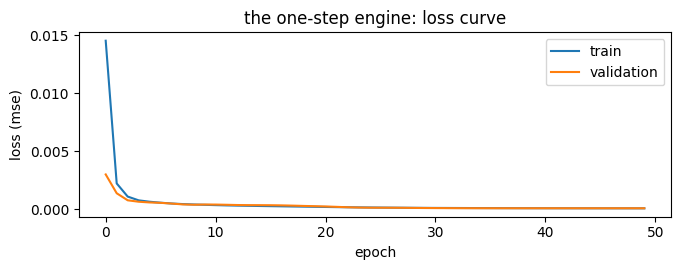

stopped after 50 epochs


one-step LSTM, 1 hour ahead: MAE 33.4 MW


In [3]:
keras.utils.set_random_seed(5509)   # re-seed right before the build, not just at import

one_step = Sequential()
one_step.add(Input(shape=(n_steps, n_features)))
one_step.add(LSTM(32))
one_step.add(Dense(1))
one_step.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = one_step.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("the one-step engine: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")

pred_1h = sc_y.inverse_transform(one_step.predict(X_test, verbose=0)).ravel()
print(f"one-step LSTM, 1 hour ahead: MAE {mean_absolute_error(y_true, pred_1h):.1f} MW")

## Rolling the one-step model forward

The engine above answers one question: *given the last 24 hours, what is demand in the next hour?* To get a whole
day, run it 24 times - and after the first run, the "last hour" it is given is **its own prediction**.

`recursive_forecast` does exactly that for every origin in the test year at once. Two things to watch in the code:

- `future[:, -1] = p` - the demand column of the next row is overwritten with **our prediction**. That one line
  is the entire autoregressive idea.
- `mode` decides what goes in the weather columns: `"persist"` freezes the last observed weather (honest),
  `"actual"` hands the model the real future weather (impossible, but it bounds how much a forecast is worth).

In [4]:
def recursive_forecast(model, seqs, n_steps, horizon, weather_cols, mode="actual"):
    """Roll a one-step model horizon steps ahead from EVERY window in seqs.
    mode='actual'  -> future weather rows come from the real future (perfect foresight - a cheat, labelled as such)
    mode='persist' -> future weather is frozen at the last observed hour (what you'd have with no forecast)"""
    n_orig = len(seqs) - n_steps - horizon + 1

    # every origin's starting window: 24 real hours of history
    window = []
    for i in range(n_orig):
        window.append(seqs[i:i+n_steps])
    window = np.array(window)                                            # (origins, 24, 8)

    preds = np.zeros((n_orig, horizon))
    for h in range(horizon):
        p = model.predict(window, verbose=0).ravel()                     # the next hour, for every origin at once
        preds[:, h] = p

        # the real row for hour +h+1. We only keep its CLOCK columns.
        future = []
        for i in range(n_orig):
            future.append(seqs[i+n_steps+h])
        future = np.array(future).copy()
        if mode == "persist":
            future[:, weather_cols] = window[:, -1, weather_cols]            # no forecast: freeze the weather
        future[:, -1] = p                                                    # the demand column is OUR PREDICTION now
        window = np.concatenate([window[:, 1:, :], future[:, None, :]], axis=1)   # slide the window
    return preds

horizon = 24
weather_cols = [feats.index(c) for c in ["BDL_tmpf", "BDL_dwpf", "BDL_relh"]]
rec_actual  = recursive_forecast(one_step, te_s, n_steps, horizon, weather_cols, mode="actual")
rec_persist = recursive_forecast(one_step, te_s, n_steps, horizon, weather_cols, mode="persist")

# the truth for the same origins and horizons
n_orig = rec_actual.shape[0]
truth = []
for i in range(n_orig):
    truth.append(te_s[i+n_steps:i+n_steps+horizon, -1])
truth = np.array(truth)

def to_mw(a):
    """Undo the target scaler, keeping the (origins, horizon) shape."""
    flat = sc_y.inverse_transform(a.reshape(-1, 1))
    return flat.reshape(a.shape)

truth_mw       = to_mw(truth)
rec_actual_mw  = to_mw(rec_actual)
rec_persist_mw = to_mw(rec_persist)

mae_rec_actual  = np.abs(rec_actual_mw  - truth_mw).mean(axis=0)
mae_rec_persist = np.abs(rec_persist_mw - truth_mw).mean(axis=0)
print("recursive, perfect-foresight weather - MAE at h=1, 6, 12, 24:", mae_rec_actual[[0, 5, 11, 23]].round(1))
print("recursive, weather frozen          - MAE at h=1, 6, 12, 24:", mae_rec_persist[[0, 5, 11, 23]].round(1))

recursive, perfect-foresight weather - MAE at h=1, 6, 12, 24: [ 33.3 159.3 236.3 330.9]
recursive, weather frozen          - MAE at h=1, 6, 12, 24: [ 33.3 167.7 265.2 413.6]


## Error by horizon: watch it fall apart

One number is not enough here. What matters is **how the error grows as the roll-forward gets further from the
last real reading**, so everything below is reported per horizon: hour 1, hour 2, ... hour 24.

Two versions of the same model are scored, and the difference between them is not the model at all - it is what
goes in the weather columns for hours that have not happened:

- **weather frozen** - no forecast at all; the last observed temperature is held for all 24 hours. This is the
  honest floor.
- **perfect weather** - the *actual* future weather is fed in. Nobody has this. It is the optimistic ceiling,
  and the gap between the two lines is what a good weather forecast is worth.

Read the table first. The picture underneath says the same thing.

In [5]:
# seasonal naive at every horizon: "the same hour yesterday", scored on the same origins
dem = test["Demand"].values
naive = []
for h in range(horizon):
    actual    = dem[n_steps+h      : n_steps+h      + n_orig]
    yesterday = dem[n_steps+h-24   : n_steps+h-24   + n_orig]
    naive.append(mean_absolute_error(actual, yesterday))
naive = np.array(naive)


In [6]:
# the table, before the picture
rows = {"recursive (frozen wx)": mae_rec_persist,
        "recursive (perfect wx)": mae_rec_actual,
        "seasonal naive": naive}

H = [0, 5, 11, 23]                          # hours 1, 6, 12, 24
board = {}
for name, curve in rows.items():
    board[name] = curve[H].round(1)
board = pd.DataFrame(board, index=["h=1", "h=6", "h=12", "h=24"]).T
display(board)

print()
for name, curve in rows.items():
    grew = curve[23] / curve[0]
    print(name.ljust(24), "h=1:", round(curve[0], 1), " h=24:", round(curve[23], 1),
          "  ->", round(grew, 1), "x worse")

,h=1,h=6,h=12,h=24
recursive (frozen wx),33.3,167.7,265.2,413.6
recursive (perfect wx),33.3,159.3,236.3,330.9
seasonal naive,227.2,227.2,226.7,226.3



recursive (frozen wx)    h=1: 33.3  h=24: 413.6   -> 12.4 x worse
recursive (perfect wx)   h=1: 33.3  h=24: 330.9   -> 9.9 x worse
seasonal naive           h=1: 227.2  h=24: 226.3   -> 1.0 x worse


**That last column is the whole lesson.** At one hour ahead the model is excellent - it is being handed 24
hours of real, measured history and asked about the very next hour. By hour 24 it has been fed **23 of its own
guesses in a row**, and the error has multiplied.

Seasonal naive barely moves. "The same hour yesterday" is exactly as good at hour 24 as at hour 1, because it is
always looking a full day back either way. That flat line is why it is such a stubborn baseline: the recursive
model beats it easily early and then has to fight for the back half of the day.

### The same numbers as a picture

Every line is one strategy, every point is one horizon. The lines that climb left to right are the error falling
apart; the flat grey one is the baseline that does not care how far ahead you ask.

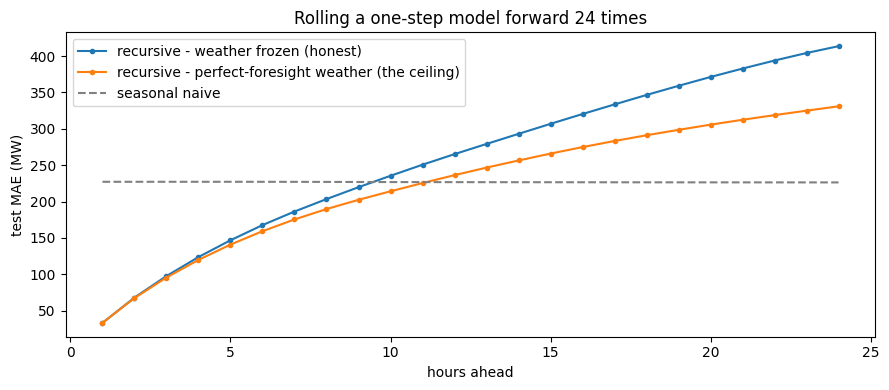

In [7]:
hrs = np.arange(1, horizon + 1)
plt.figure(figsize=(9, 4))
plt.plot(hrs, mae_rec_persist, marker=".", label="recursive - weather frozen (honest)")
plt.plot(hrs, mae_rec_actual,  marker=".", label="recursive - perfect-foresight weather (the ceiling)")
plt.plot(hrs, naive, "--", color="gray", label="seasonal naive")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)")
plt.title("Rolling a one-step model forward 24 times")
plt.legend(); plt.tight_layout(); plt.show()

## A single forecast day, up close

The table tells you the error grows. This shows you *what that looks like* - one forecast, issued at midnight,
rolling 24 hours forward against the day that actually happened.

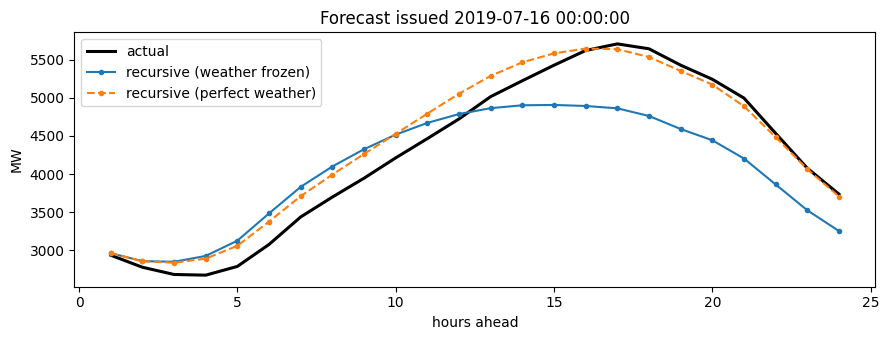

In [8]:
# ONE forecast day, up close: issued at midnight, 24 hours of roll-forward against what happened
origins = test.index[n_steps - 1 : n_steps - 1 + n_orig]     # the hour each forecast was ISSUED
o = origins.get_indexer([pd.Timestamp("2019-07-16 00:00")])[0]

hrs = np.arange(1, horizon + 1)
plt.figure(figsize=(9, 3.5))
plt.plot(hrs, truth_mw[o], "k", lw=2.2, label="actual")
plt.plot(hrs, rec_persist_mw[o], marker=".", label="recursive (weather frozen)")
plt.plot(hrs, rec_actual_mw[o], marker=".", ls="--", label="recursive (perfect weather)")
plt.xlabel("hours ahead"); plt.ylabel("MW")
plt.title("Forecast issued " + str(origins[o]))
plt.legend(); plt.tight_layout(); plt.show()

## Four days across the year

One day could be luck. These are four forecasts issued at midnight in four different seasons, each rolled the
full 24 hours. Look for two things: **where in the day** the forecast comes apart, and whether the frozen-weather
version and the perfect-weather version separate - because when they do, the weather forecast was the thing that
mattered, not the model.

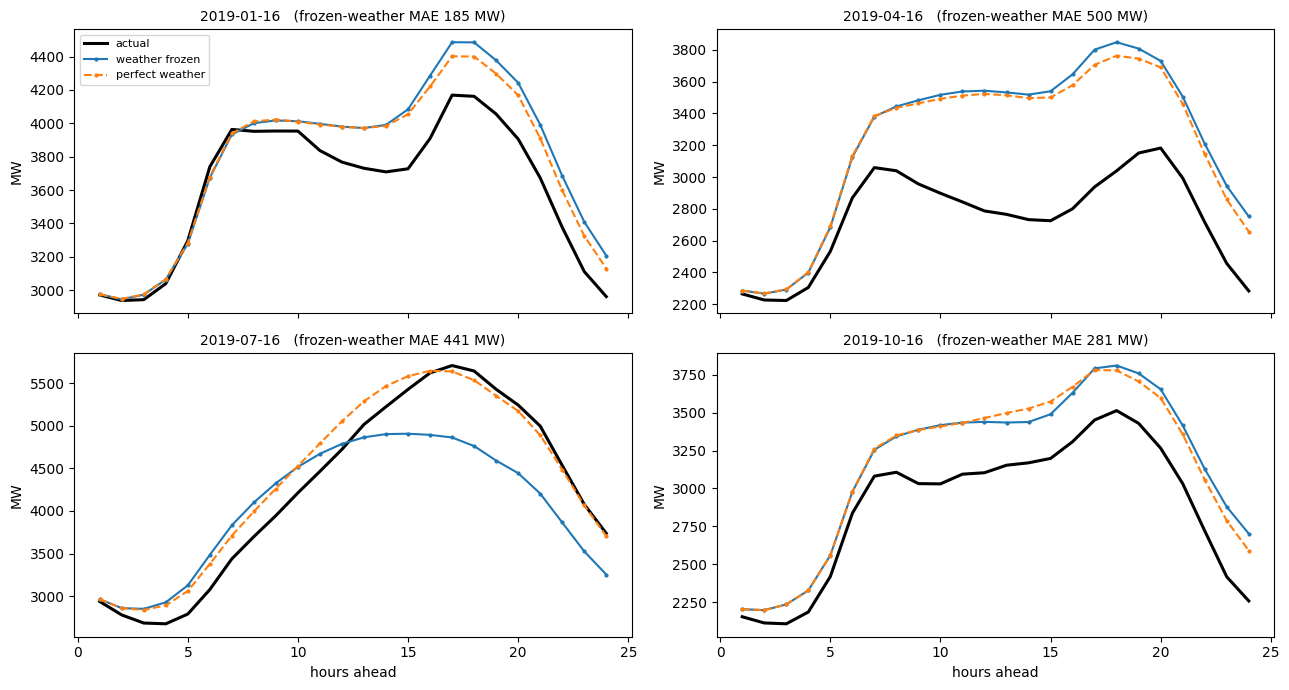

In [9]:
sample_days = ["2019-01-16", "2019-04-16", "2019-07-16", "2019-10-16"]

fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
ax = ax.ravel()

for panel, day in enumerate(sample_days):
    o = origins.get_indexer([pd.Timestamp(day + " 00:00")])[0]
    a = ax[panel]
    a.plot(hrs, truth_mw[o], "k", lw=2.2, label="actual")
    a.plot(hrs, rec_persist_mw[o], marker=".", ms=4, label="weather frozen")
    a.plot(hrs, rec_actual_mw[o], marker=".", ms=4, ls="--", label="perfect weather")

    err = np.abs(rec_persist_mw[o] - truth_mw[o]).mean()
    a.set_title(day + "   (frozen-weather MAE " + str(round(err)) + " MW)", fontsize=10)
    a.set_ylabel("MW")
    if panel >= 2:
        a.set_xlabel("hours ahead")

ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What to look for.** The first few hours sit on the black line in every season - that is the model doing the
job it was trained for. The overnight trough is usually fine too. The afternoon is where it goes, because that is
both the furthest from the last real reading **and** the part of the day that depends most on temperature.

That is also where the two lines separate. When frozen-weather and perfect-weather agree, the weather did not
matter that day. When they fan apart, you are looking at the price of not having a forecast.

## Where do the future covariates come from?

The roll-forward forced this question, and it is the real content of the notebook. Every column in the window has
to be filled for hours that have not happened. There are exactly three kinds:

| column | at hour +h you actually have... | what to do |
| :-- | :-- | :-- |
| **calendar / clock** (hour, weekday, holiday) | the exact value - it is a calendar | use it. It is free, and after demand's own past it is the strongest thing you have |
| **weather** (temperature, dew point, humidity) | *not* the actual - only a **forecast** | feed the NWS forecast for hour +h. Its error becomes your error, so validate against *archived forecasts*, never actuals - the "perfect weather" line above is a ceiling you will not reach |
| **the target's own past** (demand) | actuals up to now, then nothing | this is the trap: recursive has to feed in its own predictions, and they compound |

That third row is why the frozen-weather curve climbs the way it does. Nothing is wrong with the model - it is
being asked, by hour 24, to make a prediction from a window that is almost entirely its own guesses.

**Two honest ways out**, both for a later course: train a separate model for each horizon so nothing is ever fed
back, or give the model a `Dense(24)` head and have it produce the whole day at once. Both appear in the diagram
at the top.

## Save the model and use it again

In [10]:
one_step.save('A5_one_step_engine.keras')
reloaded = load_model('A5_one_step_engine.keras')
print("reloaded model reproduces the forecast:",
      np.allclose(one_step.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Roll forward from a **week** of history (`n_steps = 168`) instead of a day. Does the longer window slow the
  error growth, or does the compounding swamp it either way?
- Replace the frozen weather with **yesterday's weather at the same hour** - a poor person's forecast. Where does
  it land between the two curves you already have?
- Forecast **48 hours** instead of 24. Where does the recursive curve cross seasonal naive?
- Add a `holiday` column (`pandas.tseries.holiday.USFederalHolidayCalendar`). It is a calendar covariate, so you
  know it perfectly in advance - exactly the free kind from the table above.
- Pick the **worst** forecast day in the test year (largest MAE) and plot it next to the best one. What was
  different about that day?